# **Cálculo del Peligro Esperado (xT) en el Fútbol**

### Estimación de la probabilidad de marcar un gol en las próximas 5 acciones

In [1]:
from statsbombpy import sb
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)

# Partidos del Mundial Rusia y Qatar

Descargo partidos de Rusia 2018.

In [2]:
df_partidos_rusia = sb.matches(competition_id=43, season_id=3)

df_partidos_rusia["mundial"] = "Rusia 2018"

c:\Users\Malcolm\anaconda3\envs\patrones-lab-py312-clean\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [3]:
df_partidos_rusia.head().T

,0,1,2,3,4
match_id,7585,7570,7586,7557,7542
match_date,2018-07-03,2018-06-28,2018-07-03,2018-06-25,2018-06-20
kick_off,20:00:00.000,20:00:00.000,16:00:00.000,20:00:00.000,14:00:00.000
home_score,1,0,1,1,1
away_score,1,1,0,1,0
match_status,available,available,available,available,available
match_status_360,scheduled,scheduled,scheduled,scheduled,scheduled
last_updated,2023-07-24T13:06:27.791230,2023-07-24T13:06:39.637575,2023-07-24T13:05:18.578795,2023-07-24T13:03:08.956903,2023-07-24T13:02:10.657273
last_updated_360,2021-06-13T16:17:31.694,2021-06-13T16:17:31.694,2021-06-13T16:17:31.694,2021-06-13T16:17:31.694,2021-06-13T16:17:31.694
match_week,4,3,4,3,2


Descargo partidos de Qatar 2022.

In [4]:
df_partidos_qatar = sb.matches(competition_id=43, season_id=106)

df_partidos_qatar["mundial"] = "Qatar 2022"

c:\Users\Malcolm\anaconda3\envs\patrones-lab-py312-clean\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Unifico tablas de los dos mundiales.

In [5]:
df_partidos_mundiales = pd.concat([df_partidos_rusia, df_partidos_qatar],ignore_index=True)

In [6]:
df_partidos_mundiales["mundial"].value_counts()

mundial
Rusia 2018    64
Qatar 2022    64
Name: count, dtype: int64

In [7]:
columnas_partidos = [
    "mundial",
    "match_id",
    "match_date",
    "competition_stage",
    "home_team",
    "away_team",
    "home_score",
    "away_score"
]

df_partidos_mundiales[columnas_partidos].sort_values(["mundial", "match_date"]).head(10)

,mundial,match_id,match_date,competition_stage,home_team,away_team,home_score,away_score
99,Qatar 2022,3857286,2022-11-20,Group Stage,Qatar,Ecuador,0,2
98,Qatar 2022,3857282,2022-11-21,Group Stage,United States,Wales,1,1
110,Qatar 2022,3857285,2022-11-21,Group Stage,Senegal,Netherlands,0,2
121,Qatar 2022,3857271,2022-11-21,Group Stage,England,Iran,6,2
101,Qatar 2022,3857300,2022-11-22,Group Stage,Argentina,Saudi Arabia,1,2
113,Qatar 2022,3857279,2022-11-22,Group Stage,France,Australia,4,1
123,Qatar 2022,3857265,2022-11-22,Group Stage,Mexico,Poland,0,0
127,Qatar 2022,3857254,2022-11-22,Group Stage,Denmark,Tunisia,0,0
97,Qatar 2022,3857284,2022-11-23,Group Stage,Germany,Japan,1,2
108,Qatar 2022,3857291,2022-11-23,Group Stage,Spain,Costa Rica,7,0


In [8]:
df_partidos_mundiales["away_score"].sum() + df_partidos_mundiales["home_score"].sum()

341

In [9]:
df_partidos_mundiales["competition_stage"].value_counts()

competition_stage
Group Stage        96
Round of 16        16
Quarter-finals      8
Semi-finals         4
Final               2
3rd Place Final     2
Name: count, dtype: int64

# Eventos de Partidos de Rusia y Qatar

Descargo eventos de todos los partidos.

In [10]:
lista_eventos = []

for i in range(len(df_partidos_mundiales)):
    
    match_id = df_partidos_mundiales.loc[i, "match_id"]
    mundial = df_partidos_mundiales.loc[i, "mundial"]
    competition_id = df_partidos_mundiales.loc[i, "competition_id"]
    season_id = df_partidos_mundiales.loc[i, "season_id"]
    
    print("Descargando eventos:", mundial, "-", match_id)
    
    df_eventos_partido = sb.events(match_id=match_id)
    
    df_eventos_partido["match_id"] = match_id
    df_eventos_partido["mundial"] = mundial
    df_eventos_partido["competition_id"] = competition_id
    df_eventos_partido["season_id"] = season_id
    
    lista_eventos.append(df_eventos_partido)

Descargando eventos: Rusia 2018 - 7585


c:\Users\Malcolm\anaconda3\envs\patrones-lab-py312-clean\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Descargando eventos: Rusia 2018 - 7570


c:\Users\Malcolm\anaconda3\envs\patrones-lab-py312-clean\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Descargando eventos: Rusia 2018 - 7586


...

c:\Users\Malcolm\anaconda3\envs\patrones-lab-py312-clean\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Descargando eventos: Qatar 2022 - 3857255


c:\Users\Malcolm\anaconda3\envs\patrones-lab-py312-clean\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Descargando eventos: Qatar 2022 - 3857254


c:\Users\Malcolm\anaconda3\envs\patrones-lab-py312-clean\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Unifico todos los eventos descargados.

In [11]:
df_eventos_mundiales = pd.concat(lista_eventos, ignore_index=True)

In [12]:
df_eventos_mundiales.shape

(462501, 118)

In [13]:
df_eventos_mundiales["type"].value_counts()

type
Pass                 131396
Ball Receipt*        122652
Carry                104285
Pressure              40015
Ball Recovery         11499
Duel                   7530
Clearance              4758
Block                  4546
Dribble                3902
Goal Keeper            3765
Foul Committed         3651
Foul Won               3482
Miscontrol             3290
Shot                   3200
Interception           2647
Dispossessed           2620
Dribbled Past          2477
Camera On              1747
Substitution            969
Injury Stoppage         694
Half End                570
Half Start              570
Camera off              393
Tactical Shift          359
50/50                   344
Starting XI             256
Referee Ball-Drop       219
Shield                  160
Player On               137
Player Off              137
Bad Behaviour            84
Error                    65
Offside                  52
Own Goal For             15
Own Goal Against         15
Name: count, dt

In [14]:
df_eventos_mundiales["period"].value_counts().sort_index()

period
1    228968
2    222578
3      5631
4      5124
5       200
Name: count, dtype: int64

In [15]:
df_info_partidos = df_partidos_mundiales[["match_id","match_date", "competition_stage", "home_team", "away_team", "home_score", "away_score"]].copy()

Agrego datos del partido a cada evento.

In [16]:
df_eventos_mundiales = df_eventos_mundiales.merge(df_info_partidos, on="match_id", how="left")

In [17]:
df_eventos_mundiales[["mundial", "match_id", "match_date", "home_team", "away_team", "team", "player", "type"]].head()

,mundial,match_id,match_date,home_team,away_team,team,player,type
0,Rusia 2018,7585,2018-07-03,Colombia,England,Colombia,NaN,Starting XI
1,Rusia 2018,7585,2018-07-03,Colombia,England,England,NaN,Starting XI
2,Rusia 2018,7585,2018-07-03,Colombia,England,England,NaN,Half Start
3,Rusia 2018,7585,2018-07-03,Colombia,England,Colombia,NaN,Half Start
4,Rusia 2018,7585,2018-07-03,Colombia,England,Colombia,NaN,Half Start


Creo la base para calcular PE5-Gol.

In [18]:
df_pe5 = df_eventos_mundiales.copy()

Excluyo tandas de penales.

In [19]:
df_pe5 = df_pe5[df_pe5["period"] <= 4].copy()

Filtro acciones ofensivas para estimar peligro.

In [20]:
df_pe5 = df_pe5[df_pe5["type"].isin(["Pass", "Carry", "Dribble", "Shot"])].copy()

In [21]:
df_pe5["type"].value_counts()

type
Pass       131396
Carry      104285
Dribble      3902
Shot         3120
Name: count, dtype: int64

Conservo acciones con ubicación en cancha.

In [22]:
df_pe5 = df_pe5[df_pe5["location"].notna()].copy()

In [23]:
df_pe5["type"].value_counts()

type
Pass       131396
Carry      104285
Dribble      3902
Shot         3120
Name: count, dtype: int64

In [24]:
df_pe5.head(5)

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,counterpress,dribble_nutmeg,dribble_outcome,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_backheel,pass_body_part,pass_cross,pass_deflected,pass_end_location,pass_goal_assist,pass_height,pass_length,pass_outcome,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_follows_dribble,shot_freeze_frame,shot_key_pass_id,shot_open_goal,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,mundial,competition_id,season_id,block_save_block,dribble_overrun,foul_committed_offensive,injury_stoppage_in_chain,pass_cut_back,pass_technique,pass_through_ball,shot_one_on_one,ball_recovery_offensive,miscontrol_aerial_won,pass_miscommunication,shot_redirect,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,off_camera,out,pass_outswinging,pass_no_touch,pass_inswinging,pass_straight,clearance_other,dribble_no_touch,goalkeeper_punched_out,goalkeeper_shot_saved_to_post,shot_saved_to_post,half_start_late_video_start,goalkeeper_shot_saved_off_target,shot_saved_off_target,goalkeeper_success_in_play,goalkeeper_lost_in_play,match_date,competition_stage,home_team,away_team,home_score,away_score
12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d4883f20-ce68-4f84-b26a-a049a13cb6be,5,NaN,"[60.0, 40.0]",7585,0,NaN,3.041924,NaN,NaN,Left Foot,NaN,NaN,"[50.0, 41.0]",NaN,Ground Pass,10.049875,NaN,Juan Fernando Quintero Paniagua,5692.0,NaN,NaN,Kick Off,1,From Kick Off,Radamel Falcao García Zárate,3445.0,Left Center Forward,2,Colombia,769,[5fc9acb8-88c3-4cfb-ad9c-fc250c0dffde],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Colombia,769,00:00:00.240,Pass,NaN,Rusia 2018,43,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-07-03,Round of 16,Colombia,England,1,1
13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9bdb71f9-c87b-4a66-96f0-def5312ca921,9,NaN,"[51.0, 40.0]",7585,0,NaN,1.849096,NaN,NaN,Left Foot,NaN,NaN,"[47.0, 54.0]",NaN,Ground Pass,14.560220,NaN,Carlos Alberto Sánchez Moreno,5685.0,NaN,NaN,NaN,1,From Kick Off,Juan Fernando Quintero Paniagua,5692.0,Center Attacking Midfield,2,Colombia,769,"[05d8e5e5-37fe-4bad-8b21-2dbdff9b56d2, a330006...",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Colombia,769,00:00:02.120,Pass,True,Rusia 2018,43,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-07-03,Round of 16,Colombia,England,1,1
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6cb0d85d-bd14-42e3-9c2d-7f99ce437796,12,NaN,"[49.0, 55.0]",7585,0,NaN,0.982794,NaN,NaN,Right Foot,NaN,NaN,"[65.0, 79.0]",NaN,Ground Pass,28.844410,NaN,Santiago Arias Naranjo,5696.0,NaN,NaN,NaN,1,From Kick Off,Carlos Alberto Sánchez Moreno,5685.0,Right Center Midfield,2,Colombia,769,[0cf688d1-8134-4338-a5ea-e8d58dc5719e],4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Colombia,

Conservo acciones del equipo en posesión.

In [25]:
df_pe5 = df_pe5[df_pe5["team"] == df_pe5["possession_team"]].copy()

In [26]:
df_pe5[df_pe5["team"]=="Argentina"].head(5)

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,counterpress,dribble_nutmeg,dribble_outcome,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_backheel,pass_body_part,pass_cross,pass_deflected,pass_end_location,pass_goal_assist,pass_height,pass_length,pass_outcome,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_follows_dribble,shot_freeze_frame,shot_key_pass_id,shot_open_goal,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,mundial,competition_id,season_id,block_save_block,dribble_overrun,foul_committed_offensive,injury_stoppage_in_chain,pass_cut_back,pass_technique,pass_through_ball,shot_one_on_one,ball_recovery_offensive,miscontrol_aerial_won,pass_miscommunication,shot_redirect,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,off_camera,out,pass_outswinging,pass_no_touch,pass_inswinging,pass_straight,clearance_other,dribble_no_touch,goalkeeper_punched_out,goalkeeper_shot_saved_to_post,shot_saved_to_post,half_start_late_video_start,goalkeeper_shot_saved_off_target,shot_saved_off_target,goalkeeper_success_in_play,goalkeeper_lost_in_play,match_date,competition_stage,home_team,away_team,home_score,away_score
76675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2fbd63a7-0936-43be-b53d-24a6beab6ced,11,NaN,"[31.0, 21.0]",7580,0,NaN,0.018180,NaN,NaN,Right Foot,NaN,NaN,"[86.0, 22.0]",NaN,High Pass,55.009090,Incomplete,Éver Maximiliano David Banega,5504.0,NaN,NaN,Free Kick,1,From Free Kick,Franco Armani,6312.0,Goalkeeper,3,Argentina,779,"[2fc5f99b-1e0f-4364-a900-def423786a45, 9d026dc...",47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:00:47.040,Pass,NaN,Rusia 2018,43,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-06-30,Round of 16,France,Argentina,4,3
76685,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dff827f6-b953-47fe-8add-b99172d42a72,51,NaN,"[31.0, 16.0]",7580,1,NaN,-0.745420,NaN,NaN,Left Foot,NaN,NaN,"[44.0, 4.0]",NaN,Ground Pass,17.691807,NaN,Nicolás Alejandro Tagliafico,5507.0,NaN,NaN,NaN,1,Regular Play,Faustino Marcos Alberto Rojo,3602.0,Left Center Back,5,Argentina,779,[a9161226-a39a-41d1-a1b4-e8867c5eb769],28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:01:28.720,Pass,NaN,Rusia 2018,43,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-06-30,Round of 16,France,Argentina,4,3
76686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dddbaae6-f04a-41a0-9be2-339d5d03aa57,54,NaN,"[42.0, 3.0]",7580,1,NaN,2.587285,NaN,NaN,Left Foot,NaN,NaN,"[21.0, 16.0]",NaN,Ground Pass,24.698177,NaN,Faustino Marcos Alberto Rojo,3602.0,NaN,NaN,NaN,1,Regular Play,Nicolás Alejandro Tagliafico,5507.0,Left Back,5,Argentina,779,[0c80c20e-aba7-4624-bd68-7442b724baca],31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:01:31.040,Pass,N

In [27]:
df_pe5["type"].value_counts()

type
Pass       123876
Carry      100272
Dribble      3551
Shot         3092
Name: count, dtype: int64

In [28]:
df_pe5["shot_type"].value_counts()

shot_type
Open Play    2910
Free Kick     128
Penalty        52
Corner          2
Name: count, dtype: int64

Quito penales para evitar sesgo en el valor zonal.

In [29]:
df_pe5 = df_pe5[(df_pe5["shot_type"] != "Penalty") | (df_pe5["shot_type"].isna())].copy()

In [30]:
df_pe5["type"].value_counts()

type
Pass       123876
Carry      100272
Dribble      3551
Shot         3040
Name: count, dtype: int64

In [31]:
df_goles_pe5 = df_pe5[(df_pe5["type"] == "Shot") & (df_pe5["shot_outcome"] == "Goal")].copy()

df_goles_pe5["mundial"].value_counts()

mundial
Qatar 2022    149
Rusia 2018    132
Name: count, dtype: int64

Separo ubicación en coordenadas x e y.

In [32]:
df_pe5[["x", "y"]] = df_pe5["location"].apply(pd.Series)

In [33]:
df_pe5[["mundial", "match_id", "minute", "team", "player", "type", "location", "x", "y"]].head()

,mundial,match_id,minute,team,player,type,location,x,y
12,Rusia 2018,7585,0,Colombia,Radamel Falcao García Zárate,Pass,"[60.0, 40.0]",60.0,40.0
13,Rusia 2018,7585,0,Colombia,Juan Fernando Quintero Paniagua,Pass,"[51.0, 40.0]",51.0,40.0
14,Rusia 2018,7585,0,Colombia,Carlos Alberto Sánchez Moreno,Pass,"[49.0, 55.0]",49.0,55.0
15,Rusia 2018,7585,0,Colombia,Santiago Arias Naranjo,Pass,"[66.0, 78.0]",66.0,78.0
18,Rusia 2018,7585,0,Colombia,Juan Guillermo Cuadrado Bello,Pass,"[95.0, 64.0]",95.0,64.0


Asigno cada acción a una zona 10x10.

In [34]:
df_pe5["zona_x"] = (df_pe5["x"] // 10).astype(int)
df_pe5["zona_y"] = (df_pe5["y"] // 10).astype(int)

In [35]:
df_pe5.loc[df_pe5["zona_x"] > 11, "zona_x"] = 11
df_pe5.loc[df_pe5["zona_y"] > 7, "zona_y"] = 7

In [36]:
df_pe5["zona"] = df_pe5["zona_x"].astype(str) + "_" + df_pe5["zona_y"].astype(str)

In [37]:
df_pe5[["x", "y", "zona_x", "zona_y", "zona"]].head()

,x,y,zona_x,zona_y,zona
12,60.0,40.0,6,4,6_4
13,51.0,40.0,5,4,5_4
14,49.0,55.0,4,5,4_5
15,66.0,78.0,6,7,6_7
18,95.0,64.0,9,6,9_6


In [38]:
df_pe5["zona"].nunique()

96

Marco los tiros que terminaron en gol.

In [39]:
df_pe5["es_gol"] = 0

df_pe5.loc[(df_pe5["type"] == "Shot") & (df_pe5["shot_outcome"] == "Goal"), "es_gol"] = 1

In [40]:
df_pe5["es_gol"].value_counts()

es_gol
0    230458
1       281
Name: count, dtype: int64

Ordeno acciones para recorrer secuencias.

In [41]:
df_pe5 = df_pe5.sort_values(["match_id", "period", "index"]).reset_index(drop=True)

In [42]:
df_pe5["gol_ventana_5"] = 0

Loop para marcar gol en la ventana de 5 acciones.

In [43]:
for claves, grupo in df_pe5.groupby(["match_id", "possession", "team"]):
    
    indices = grupo.index.to_list()
    goles = grupo["es_gol"].to_list()
    
    for posicion in range(len(indices)):
        
        inicio = posicion
        fin = posicion + 5
        
        ventana_goles = goles[inicio:fin]
        
        if 1 in ventana_goles:
            indice_original = indices[posicion]
            df_pe5.loc[indice_original, "gol_ventana_5"] = 1

In [44]:
df_pe5["gol_ventana_5"].value_counts()

gol_ventana_5
0    229512
1      1227
Name: count, dtype: int64

In [45]:
df_pe5["gol_ventana_5"].mean() * 100

0.5317696618256992

Calculo PE5-Gol original por zona.

In [46]:
df_valor_zonas = df_pe5.groupby(["zona_x", "zona_y", "zona"]).agg(
    acciones=("id", "count"),
    goles_ventana_5=("gol_ventana_5", "sum"),
    pe5_gol=("gol_ventana_5", "mean")
).reset_index()

In [47]:
df_valor_zonas = df_valor_zonas.sort_values("pe5_gol", ascending=False)

df_valor_zonas.head(10)

,zona_x,zona_y,zona,acciones,goles_ventana_5,pe5_gol
91,11,3,11_3,480,97,0.202083
92,11,4,11_4,484,96,0.198347
84,10,4,10_4,769,69,0.089727
83,10,3,10_3,794,71,0.089421
93,11,5,11_5,628,33,0.052548
82,10,2,10_2,1255,63,0.050199
90,11,2,11_2,821,38,0.046285
85,10,5,10_5,1111,49,0.044104
75,9,3,9_3,1340,46,0.034328
76,9,4,9_4,1306,34,0.026034


In [48]:
df_valor_zonas[df_valor_zonas["acciones"] >= 50].head(10)

,zona_x,zona_y,zona,acciones,goles_ventana_5,pe5_gol
91,11,3,11_3,480,97,0.202083
92,11,4,11_4,484,96,0.198347
84,10,4,10_4,769,69,0.089727
83,10,3,10_3,794,71,0.089421
93,11,5,11_5,628,33,0.052548
82,10,2,10_2,1255,63,0.050199
90,11,2,11_2,821,38,0.046285
85,10,5,10_5,1111,49,0.044104
75,9,3,9_3,1340,46,0.034328
76,9,4,9_4,1306,34,0.026034


In [49]:
df_valor_zonas.sort_values("acciones").head(10)

,zona_x,zona_y,zona,acciones,goles_ventana_5,pe5_gol
0,0,0,0_0,249,0,0.000000
7,0,7,0_7,254,0,0.000000
1,0,1,0_1,320,0,0.000000
6,0,6,0_6,326,0,0.000000
91,11,3,11_3,480,97,0.202083
92,11,4,11_4,484,96,0.198347
2,0,2,0_2,556,1,0.001799
5,0,5,0_5,628,0,0.000000
93,11,5,11_5,628,33,0.052548
84,10,4,10_4,769,69,0.089727


In [50]:
df_valor_zonas = df_valor_zonas.sort_values(
    "pe5_gol",
    ascending=False
)

df_valor_zonas.head(20)

,zona_x,zona_y,zona,acciones,goles_ventana_5,pe5_gol
91,11,3,11_3,480,97,0.202083
92,11,4,11_4,484,96,0.198347
84,10,4,10_4,769,69,0.089727
83,10,3,10_3,794,71,0.089421
93,11,5,11_5,628,33,0.052548
82,10,2,10_2,1255,63,0.050199
90,11,2,11_2,821,38,0.046285
85,10,5,10_5,1111,49,0.044104
75,9,3,9_3,1340,46,0.034328
76,9,4,9_4,1306,34,0.026034


In [51]:
df_valor_zonas["acciones"].describe()

count      96.000000
mean     2403.531250
std      1227.799992
min       249.000000
25%      1361.750000
50%      2484.500000
75%      3371.000000
max      4684.000000
Name: acciones, dtype: float64

In [52]:
print("Zonas con datos:", df_valor_zonas["zona"].nunique())
print("Zonas posibles:", 12 * 8)

Zonas con datos: 96
Zonas posibles: 96


In [53]:
df_valor_zonas["pe5_gol"].max()

0.20208333333333334

In [54]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from mplsoccer import Pitch

Visualizo el valor PE5-Gol por zona.

C:\Users\Malcolm\AppData\Local\Temp\ipykernel_23972\500214431.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  mapa_colores = cm.get_cmap("viridis_r")


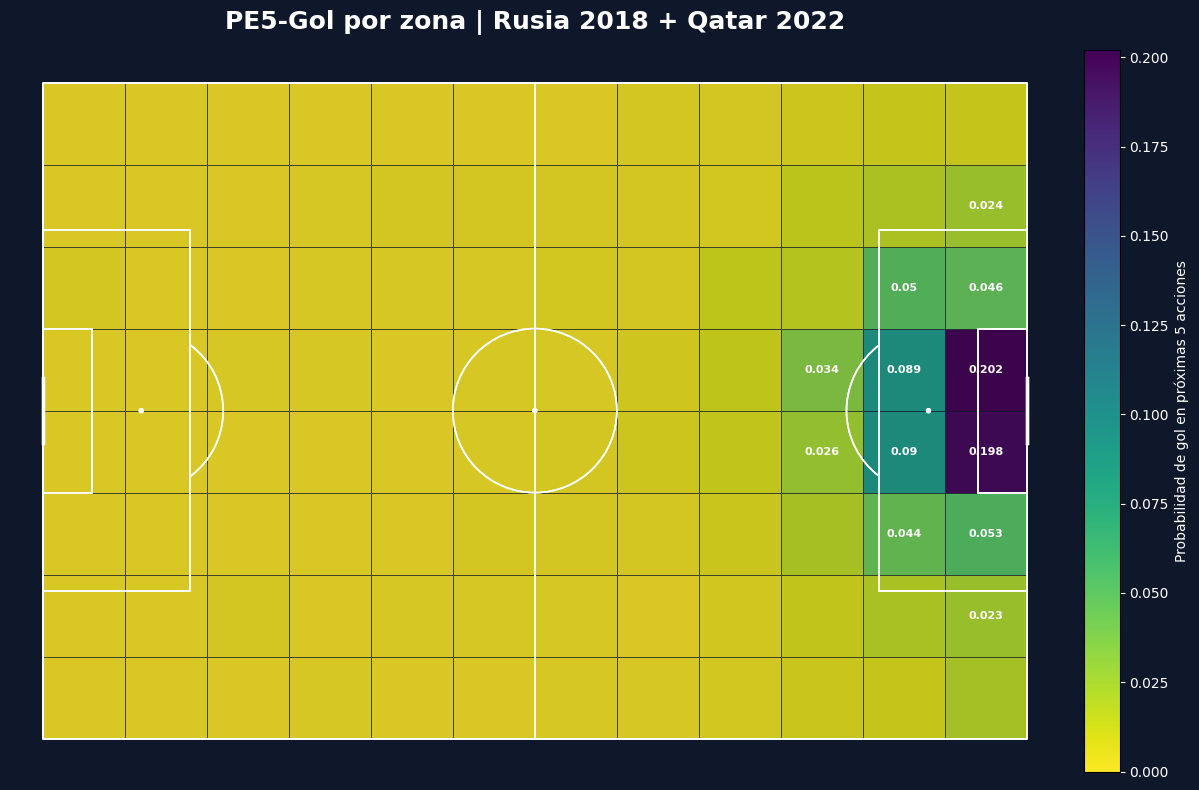

In [147]:
columna_valor = "pe5_gol"

df_mapa_zonas = df_valor_zonas.copy()

valor_minimo = 0
valor_maximo = df_mapa_zonas[columna_valor].max()

norma = Normalize(vmin=valor_minimo, vmax=valor_maximo)
mapa_colores = cm.get_cmap("viridis_r")

cancha = Pitch(
    pitch_type="statsbomb",
    pitch_color="#0f172a",
    line_color="white",
    linewidth=1.2,
    line_zorder=3)

fig, ax = cancha.draw(figsize=(13, 8))
fig.set_facecolor("#0f172a")

for i in range(len(df_mapa_zonas)):
    
    zona_x = df_mapa_zonas.iloc[i]["zona_x"]
    zona_y = df_mapa_zonas.iloc[i]["zona_y"]
    valor = df_mapa_zonas.iloc[i][columna_valor]
    acciones = df_mapa_zonas.iloc[i]["acciones"]
    
    x_inicio = zona_x * 10
    y_inicio = zona_y * 10
    
    color = mapa_colores(norma(valor))
    
    rectangulo = patches.Rectangle(
        (x_inicio, y_inicio),
        10,
        10,
        facecolor=color,
        edgecolor="#0f172a",
        linewidth=0.5,
        alpha=0.85)
    
    ax.add_patch(rectangulo)
    
    if acciones >= 50 and valor >= 0.02:
        ax.text(
            x_inicio + 5,
            y_inicio + 5,
            round(valor, 3),
            ha="center",
            va="center",
            color="white",
            fontsize=8,
            fontweight="bold")

cancha.draw(ax=ax)

ax.set_title(
    "PE5-Gol por zona | Rusia 2018 + Qatar 2022",
    color="white",
    fontsize=18,
    pad=15,
    fontweight="bold")

sm = cm.ScalarMappable(cmap=mapa_colores, norm=norma)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Probabilidad de gol en próximas 5 acciones", color="white")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.get_yticklabels(), color="white")

plt.show()

Preparo tabla zona-valor para valorar acciones.

In [56]:
df_zonas_valor = df_valor_zonas[["zona", "pe5_gol"]].copy()

df_zonas_valor = df_zonas_valor.rename(columns={"pe5_gol": "valor_zona"})

Valoro pases por cambio de zona.

In [57]:
df_pases_valor = df_pe5[(df_pe5["type"] == "Pass") &(df_pe5["pass_outcome"].isna()) &(df_pe5["pass_end_location"].notna())].copy()

In [58]:
df_pases_valor[["x_fin", "y_fin"]] = df_pases_valor["pass_end_location"].apply(pd.Series)

In [59]:
df_pases_valor["zona_x_fin"] = (df_pases_valor["x_fin"] // 10).astype(int)
df_pases_valor["zona_y_fin"] = (df_pases_valor["y_fin"] // 10).astype(int)

df_pases_valor.loc[df_pases_valor["zona_x_fin"] > 11, "zona_x_fin"] = 11
df_pases_valor.loc[df_pases_valor["zona_y_fin"] > 7, "zona_y_fin"] = 7

df_pases_valor["zona_destino"] = (
    df_pases_valor["zona_x_fin"].astype(str) + "_" +
    df_pases_valor["zona_y_fin"].astype(str))

In [60]:
df_pases_valor = df_pases_valor.merge(df_zonas_valor,on="zona",how="left")

df_pases_valor = df_pases_valor.rename(columns={"valor_zona": "valor_origen"})

In [61]:
df_zonas_destino = df_zonas_valor.copy()

df_zonas_destino = df_zonas_destino.rename(columns={"zona": "zona_destino","valor_zona": "valor_destino"})

df_pases_valor = df_pases_valor.merge(df_zonas_destino,on="zona_destino",how="left")

In [62]:
df_pases_valor["incremento_pe5"] = (df_pases_valor["valor_destino"] - df_pases_valor["valor_origen"])

df_pases_valor["tipo_accion_valorada"] = "Pass"

Valoro conducciones por cambio de zona.

In [63]:
df_carries_valor = df_pe5[(df_pe5["type"] == "Carry") & (df_pe5["carry_end_location"].notna())].copy()

In [64]:
df_carries_valor[["x_fin", "y_fin"]] = df_carries_valor["carry_end_location"].apply(pd.Series)

In [65]:
df_carries_valor["zona_x_fin"] = (df_carries_valor["x_fin"] // 10).astype(int)
df_carries_valor["zona_y_fin"] = (df_carries_valor["y_fin"] // 10).astype(int)

df_carries_valor.loc[df_carries_valor["zona_x_fin"] > 11, "zona_x_fin"] = 11
df_carries_valor.loc[df_carries_valor["zona_y_fin"] > 7, "zona_y_fin"] = 7

df_carries_valor["zona_destino"] = (df_carries_valor["zona_x_fin"].astype(str) + "_" + df_carries_valor["zona_y_fin"].astype(str))

In [66]:
df_carries_valor = df_carries_valor.merge(df_zonas_valor,on="zona",how="left")

df_carries_valor = df_carries_valor.rename(columns={"valor_zona": "valor_origen"})

In [67]:
df_carries_valor = df_carries_valor.merge(df_zonas_destino, on="zona_destino",how="left")

In [68]:
df_carries_valor["incremento_pe5"] = (df_carries_valor["valor_destino"] - df_carries_valor["valor_origen"])

df_carries_valor["tipo_accion_valorada"] = "Carry"

Unifico pases y conducciones valoradas.

In [69]:
df_acciones_valoradas = pd.concat([df_pases_valor, df_carries_valor],ignore_index=True)

In [70]:
df_acciones_valoradas[["mundial","match_id","team","player","tipo_accion_valorada","zona","zona_destino","valor_origen","valor_destino","incremento_pe5"]].head()

,mundial,match_id,team,player,tipo_accion_valorada,zona,zona_destino,valor_origen,valor_destino,incremento_pe5
0,Rusia 2018,7525,Saudi Arabia,Mohammad Ibrahim Al Sahlawi,Pass,6_4,3_3,0.001929,0.001477,-0.000452
1,Rusia 2018,7525,Saudi Arabia,Salman Mohammed Al Faraj,Pass,7_0,9_0,0.001933,0.005399,0.003466
2,Rusia 2018,7525,Saudi Arabia,Salem Mohammed Al Dawsari,Pass,9_0,10_0,0.005399,0.007937,0.002538
3,Rusia 2018,7525,Saudi Arabia,Salman Mohammed Al Faraj,Pass,10_2,10_1,0.050199,0.017219,-0.032981
4,Rusia 2018,7525,Saudi Arabia,Yasir Gharsan Al Shahrani,Pass,10_1,9_1,0.017219,0.011438,-0.005781


Separo aportes positivos y negativos de PE5.

In [71]:
df_acciones_valoradas["pe5_positivo"] = 0
df_acciones_valoradas["pe5_negativo"] = 0

df_acciones_valoradas.loc[df_acciones_valoradas["incremento_pe5"] > 0,"pe5_positivo"] = df_acciones_valoradas["incremento_pe5"]

df_acciones_valoradas.loc[df_acciones_valoradas["incremento_pe5"] < 0,"pe5_negativo"] = df_acciones_valoradas["incremento_pe5"]

C:\Users\Malcolm\AppData\Local\Temp\ipykernel_23972\1775980550.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[3.46608620e-03 2.53758772e-03 8.01384715e-05 ... 9.66732597e-05
 1.55955810e-02 2.27424174e-02]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_acciones_valoradas.loc[df_acciones_valoradas["incremento_pe5"] > 0,"pe5_positivo"] = df_acciones_valoradas["incremento_pe5"]
C:\Users\Malcolm\AppData\Local\Temp\ipykernel_23972\1775980550.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-4.52332832e-04 -3.29806601e-02 -5.78063455e-03 ... -4.61596143e-04
 -6.71623761e-05 -5.71300644e-04]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_acciones_valoradas.loc[df_acciones_valoradas["incremento_pe5"] < 0,"pe5_negativo"] = df_accio

Filtro acciones valoradas de Argentina.

In [72]:
df_acciones_argentina = df_acciones_valoradas[df_acciones_valoradas["team"] == "Argentina"].copy()

Calculo ranking de jugadores por PE5.

In [73]:
df_ranking_jugadores_arg = df_acciones_argentina.groupby(["mundial", "player"]).agg(
    acciones_valoradas=("incremento_pe5", "count"),
    pe5_total=("incremento_pe5", "sum"),
    pe5_positivo=("pe5_positivo", "sum"),
    pe5_negativo=("pe5_negativo", "sum")).reset_index()

In [74]:
df_ranking_jugadores_arg = df_ranking_jugadores_arg.sort_values("pe5_total",ascending=False)

df_ranking_jugadores_arg.head(20)

,mundial,player,acciones_valoradas,pe5_total,pe5_positivo,pe5_negativo
13,Qatar 2022,Lionel Andrés Messi Cuccittini,685,3.355295,3.969799,-0.614504
22,Qatar 2022,Ángel Fabián Di María Hernández,307,1.884559,2.186577,-0.302018
33,Rusia 2018,Lionel Andrés Messi Cuccittini,410,1.644960,2.329731,-0.684771
42,Rusia 2018,Ángel Fabián Di María Hernández,141,1.058007,1.284113,-0.226106
43,Rusia 2018,Éver Maximiliano David Banega,370,0.862628,1.169973,-0.307345
15,Qatar 2022,Marcos Javier Acuña,334,0.830559,1.018146,-0.187587
20,Qatar 2022,Rodrigo Javier De Paul,920,0.695025,1.250474,-0.555450
4,Qatar 2022,Enzo Fernandez,782,0.617519,0.991062,-0.373543
36,Rusia 2018,Maximiliano Eduardo Meza,191,0.602798,0.783356,-0.180557
32,Rusia 2018,Javier Alejandro Mascherano,567,0.500391,0.814064,-0.313673


Calculo PE5 por jugador y tipo de acción.

In [75]:
df_ranking_tipo_accion = df_acciones_argentina.groupby(["mundial", "player", "tipo_accion_valorada"]).agg(
    acciones_valoradas=("incremento_pe5", "count"),
    pe5_total=("incremento_pe5", "sum"),
    pe5_positivo=("pe5_positivo", "sum"),
    pe5_negativo=("pe5_negativo", "sum")).reset_index()

In [76]:
df_ranking_tipo_accion.sort_values("pe5_total",ascending=False).head(20)

,mundial,player,tipo_accion_valorada,acciones_valoradas,pe5_total,pe5_positivo,pe5_negativo
27,Qatar 2022,Lionel Andrés Messi Cuccittini,Pass,304,1.997274,2.344422,-0.347148
26,Qatar 2022,Lionel Andrés Messi Cuccittini,Carry,381,1.358021,1.625377,-0.267356
45,Qatar 2022,Ángel Fabián Di María Hernández,Pass,126,1.242724,1.486965,-0.244241
67,Rusia 2018,Lionel Andrés Messi Cuccittini,Pass,163,0.957791,1.215766,-0.257974
85,Rusia 2018,Ángel Fabián Di María Hernández,Pass,60,0.841304,0.977162,-0.135857
66,Rusia 2018,Lionel Andrés Messi Cuccittini,Carry,247,0.687168,1.113965,-0.426797
31,Qatar 2022,Marcos Javier Acuña,Pass,169,0.654377,0.784979,-0.130602
87,Rusia 2018,Éver Maximiliano David Banega,Pass,180,0.649645,0.856166,-0.206521
44,Qatar 2022,Ángel Fabián Di María Hernández,Carry,181,0.641835,0.699612,-0.057777
41,Qatar 2022,Rodrigo Javier De Paul,Pass,469,0.467446,0.836102,-0.368656


In [77]:
df_top_acciones_arg = df_acciones_argentina.sort_values("incremento_pe5",ascending=False)

df_top_acciones_arg[["mundial","match_id","minute","team","player","tipo_accion_valorada","zona","zona_destino","valor_origen","valor_destino","incremento_pe5"]].head(20)

,mundial,match_id,minute,team,player,tipo_accion_valorada,zona,zona_destino,valor_origen,valor_destino,incremento_pe5
97078,Qatar 2022,3869321,12,Argentina,Marcos Javier Acuña,Pass,8_0,11_3,0.002013,0.202083,0.200070
88430,Qatar 2022,3857300,100,Argentina,Ángel Fabián Di María Hernández,Pass,8_6,11_3,0.003223,0.202083,0.198861
2214,Rusia 2018,7531,3,Argentina,Lionel Andrés Messi Cuccittini,Pass,8_0,11_4,0.002013,0.198347,0.196334
37510,Rusia 2018,7580,92,Argentina,Lionel Andrés Messi Cuccittini,Pass,8_5,11_3,0.006228,0.202083,0.195855
97413,Qatar 2022,3869321,47,Argentina,Lionel Andrés Messi Cuccittini,Pass,11_0,11_3,0.007947,0.202083,0.194136
2407,Rusia 2018,7531,26,Argentina,Ángel Fabián Di María Hernández,Pass,11_0,11_3,0.007947,0.202083,0.194136
88299,Qatar 2022,3857300,68,Argentina,Lionel Andrés Messi Cuccittini,Pass,11_0,11_3,0.007947,0.202083,0.194136
101291,Qatar 2022,3869519,41,Argentina,Lionel Andrés Messi Cuccittini,Pass,11_0,11_3,0.007947,0.202083,0.194136
97978,Qatar 2022,3869321,115,Argentina,Ángel Fabián Di María Hernández,Pass,11_0,11_3,0.007947,0.202083,0.194136
2866,Rusia 2018,7531,77,Argentina,Javier Alejandro Mascherano,Pass,8_4,11_3,0.008806,0.202083,0.193278


In [78]:
df_acciones_valoradas["incremento_pe5"].describe()

count    204694.000000
mean          0.001664
std           0.012907
min          -0.184630
25%          -0.000206
50%           0.000000
75%           0.000660
max           0.200486
Name: incremento_pe5, dtype: float64

In [79]:
df_acciones_valoradas.sort_values("incremento_pe5", ascending=False).head(20)

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,counterpress,dribble_nutmeg,dribble_outcome,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_backheel,pass_body_part,pass_cross,pass_deflected,pass_end_location,pass_goal_assist,pass_height,pass_length,pass_outcome,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_follows_dribble,shot_freeze_frame,shot_key_pass_id,shot_open_goal,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,mundial,competition_id,season_id,block_save_block,dribble_overrun,foul_committed_offensive,injury_stoppage_in_chain,pass_cut_back,pass_technique,pass_through_ball,shot_one_on_one,ball_recovery_offensive,miscontrol_aerial_won,pass_miscommunication,shot_redirect,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,off_camera,out,pass_outswinging,pass_no_touch,pass_inswinging,pass_straight,clearance_other,dribble_no_touch,goalkeeper_punched_out,goalkeeper_shot_saved_to_post,shot_saved_to_post,half_start_late_video_start,goalkeeper_shot_saved_off_target,shot_saved_off_target,goalkeeper_success_in_play,goalkeeper_lost_in_play,match_date,competition_stage,home_team,away_team,home_score,away_score,x,y,zona_x,zona_y,zona,es_gol,gol_ventana_5,x_fin,y_fin,zona_x_fin,zona_y_fin,zona_destino,valor_origen,valor_destino,incremento_pe5,tipo_accion_valorada,pe5_positivo,pe5_negativo
29880,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.680000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,b0737c55-fba6-4cff-a25e-8adea48ff5fc,3623,NaN,"[24.0, 62.0]",7567,95,NaN,-0.312042,d92cf55d-e4aa-417e-98f9-4733a05215c0,NaN,Left Foot,NaN,NaN,"[117.0, 32.0]",True,High Pass,97.718990,NaN,Heung-Min Son,3083.0,NaN,NaN,NaN,2,From Counter,Se-Jong Ju,5988.0,Right Midfield,182,South Korea,791,"[1eca6bec-524d-4fea-a469-56cdb457ae5e, 9de8273...",46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,South Korea,791,00:50:46.760,Pass,True,Rusia 2018,43,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-06-27,Group Stage,South Korea,Germany,2,0,24.0,62.0,2,6,2_6,0,1,117.0,32.0,11,3,11_3,0.001597,0.202083,0.200486,Pass,0.200486,0.0
21601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.399000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3b5ffdf2-f808-412e-8c9f-7a874aff50c7,2970,NaN,"[75.0, 53.0]",7556,91,NaN,-0.548549,NaN,NaN,Right Foot,NaN,NaN,"[111.0, 31.0]",NaN,High Pass,42.190044,NaN,Cheikh N''Doye,5676.0,NaN,NaN,NaN,2,From Free Kick,Moussa Wagué,5674.0,Right Back,163,Senegal,787,[e42b3b44-d599-4299-80f7-afbcca6b168e],48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Senegal,787,00:46:48.013,Pass,NaN,Rusia 2018,43,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-06-24,Group Stage,Japan,Senegal,2,2,75.0,53.0,7,5,7_5,0,0,111.0,31.0,11,3,11_3,0.001719,0.202083,0.200364,Pass,0.200364,0.0
8760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.640000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,b04a4366-2bad-4b9e-94c3-de42fe4a4af3,3224,NaN,"[79.0, 57.0]",7539,85,Na

In [80]:
df_acciones_valoradas.sort_values("incremento_pe5").head(20)

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,counterpress,dribble_nutmeg,dribble_outcome,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_backheel,pass_body_part,pass_cross,pass_deflected,pass_end_location,pass_goal_assist,pass_height,pass_length,pass_outcome,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_follows_dribble,shot_freeze_frame,shot_key_pass_id,shot_open_goal,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,mundial,competition_id,season_id,block_save_block,dribble_overrun,foul_committed_offensive,injury_stoppage_in_chain,pass_cut_back,pass_technique,pass_through_ball,shot_one_on_one,ball_recovery_offensive,miscontrol_aerial_won,pass_miscommunication,shot_redirect,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,off_camera,out,pass_outswinging,pass_no_touch,pass_inswinging,pass_straight,clearance_other,dribble_no_touch,goalkeeper_punched_out,goalkeeper_shot_saved_to_post,shot_saved_to_post,half_start_late_video_start,goalkeeper_shot_saved_off_target,shot_saved_off_target,goalkeeper_success_in_play,goalkeeper_lost_in_play,match_date,competition_stage,home_team,away_team,home_score,away_score,x,y,zona_x,zona_y,zona,es_gol,gol_ventana_5,x_fin,y_fin,zona_x_fin,zona_y_fin,zona_destino,valor_origen,valor_destino,incremento_pe5,tipo_accion_valorada,pe5_positivo,pe5_negativo
97414,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.098911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a94fa17a-4f88-474d-976d-30e9e7515cf6,1999,NaN,"[115.1, 30.7]",3869321,47,True,1.884734,NaN,NaN,NaN,NaN,NaN,"[102.6, 69.2]",NaN,Low Pass,40.478390,NaN,Lisandro Martínez,27768.0,NaN,NaN,NaN,2,From Corner,Alexis Mac Allister,27886.0,Left Center Midfield,86,Argentina,779,"[8e5ae78a-3601-45be-88f9-55e1cac2e02f, 9c8c18b...",23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:02:23.487,Pass,True,Qatar 2022,43,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-12-09,Quarter-finals,Netherlands,Argentina,2,2,115.1,30.7,11,3,11_3,0,0,102.6,69.2,10,6,10_6,0.202083,0.017453,-0.184630,Pass,0.0,-0.184630
85408,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.008185,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80b1b17c-c3b1-4d76-804a-2c89c4a5a5fb,282,NaN,"[111.1, 41.3]",3857297,7,True,-1.841200,NaN,NaN,NaN,NaN,NaN,"[103.2, 12.8]",NaN,Low Pass,29.574652,NaN,Mohammed Kanoo,5713.0,NaN,NaN,NaN,1,From Corner,Saleh Khalid Al Shehri,51469.0,Center Forward,18,Saudi Arabia,799,"[12853734-4eb1-4d0a-926c-60f001177714, f565f10...",55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Saudi Arabia,799,00:07:55.868,Pass,True,Qatar 2022,43,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-11-26,Group Stage,Poland,Saudi Arabia,2,0,111.1,41.3,11,4,11_4,0,0,103.2,12.8,10,1,10_1,0.198347,0.017219,-0.181129,Pass,0.0,-0.181129
42569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.053000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,df1e3422-0dcd-4c1d-993f-771b551fef2f,

C:\Users\Malcolm\AppData\Local\Temp\ipykernel_23972\606872575.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  mapa_colores = cm.get_cmap("magma")


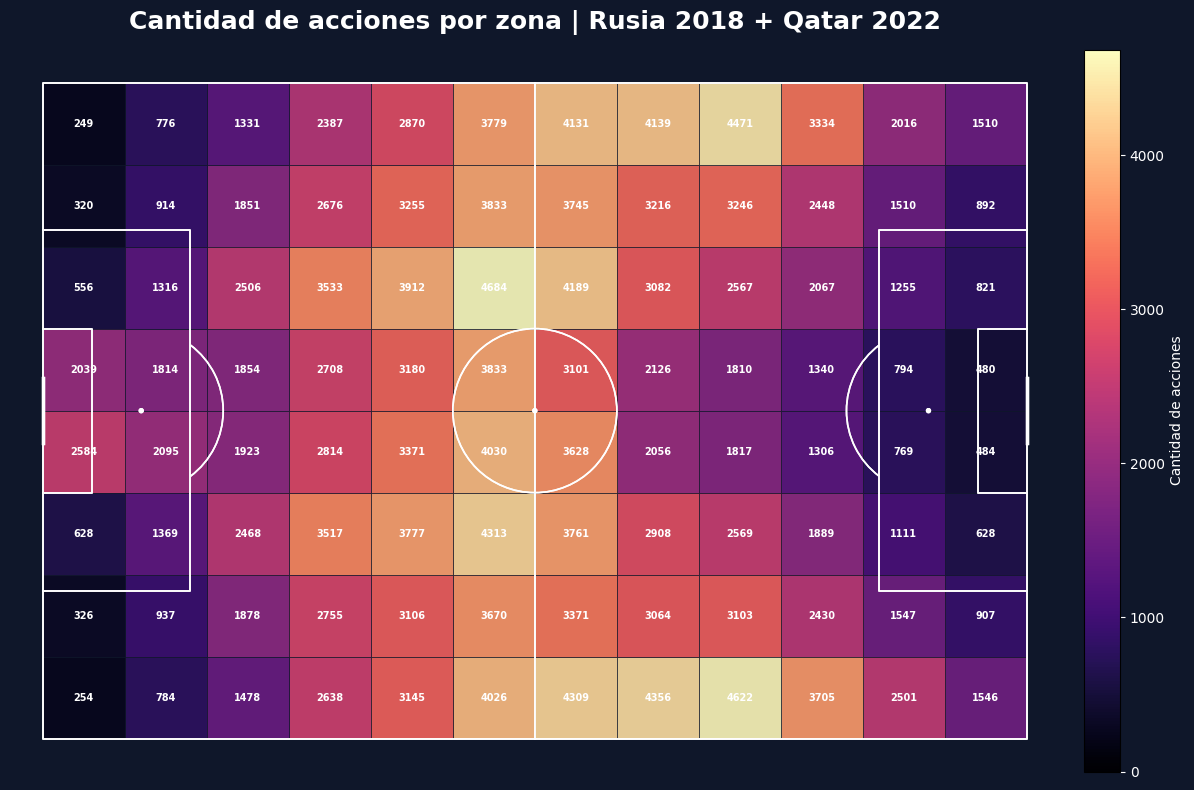

In [148]:
columna_valor = "acciones"

df_mapa = df_valor_zonas.copy()

valor_minimo = 0
valor_maximo = df_mapa[columna_valor].max()

norma = Normalize(vmin=valor_minimo, vmax=valor_maximo)
mapa_colores = cm.get_cmap("magma")

cancha = Pitch(
    pitch_type="statsbomb",
    pitch_color="#0f172a",
    line_color="white",
    linewidth=1.2,
    line_zorder=3
)

fig, ax = cancha.draw(figsize=(13, 8))
fig.set_facecolor("#0f172a")

for i in range(len(df_mapa)):
    
    zona_x = df_mapa.iloc[i]["zona_x"]
    zona_y = df_mapa.iloc[i]["zona_y"]
    acciones = df_mapa.iloc[i]["acciones"]
    
    x_inicio = zona_x * 10
    y_inicio = zona_y * 10
    
    color = mapa_colores(norma(acciones))
    
    rectangulo = patches.Rectangle(
        (x_inicio, y_inicio),
        10,
        10,
        facecolor=color,
        edgecolor="#0f172a",
        linewidth=0.5,
        alpha=0.90
    )
    
    ax.add_patch(rectangulo)
    
    ax.text(
        x_inicio + 5,
        y_inicio + 5,
        int(acciones),
        ha="center",
        va="center",
        color="white",
        fontsize=7,
        fontweight="bold"
    )

cancha.draw(ax=ax)

ax.set_title(
    "Cantidad de acciones por zona | Rusia 2018 + Qatar 2022",
    color="white",
    fontsize=18,
    pad=15,
    fontweight="bold"
)

sm = cm.ScalarMappable(cmap=mapa_colores, norm=norma)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Cantidad de acciones", color="white")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.get_yticklabels(), color="white")

plt.show()

In [82]:
df_valor_zonas["acciones"].describe()

count      96.000000
mean     2403.531250
std      1227.799992
min       249.000000
25%      1361.750000
50%      2484.500000
75%      3371.000000
max      4684.000000
Name: acciones, dtype: float64

In [83]:
df_zonas_valor = df_valor_zonas[["zona", "pe5_gol"]].copy()

df_zonas_valor = df_zonas_valor.rename(columns={"pe5_gol": "valor_zona"})

df_zonas_valor.head()

,zona,valor_zona
91,11_3,0.202083
92,11_4,0.198347
84,10_4,0.089727
83,10_3,0.089421
93,11_5,0.052548


In [84]:
df_pases_valor = df_pe5[(df_pe5["type"] == "Pass") & (df_pe5["pass_outcome"].isna()) & (df_pe5["pass_end_location"].notna())].copy()

df_pases_valor.shape

(104422, 131)

In [85]:
df_pases_valor[["x_fin", "y_fin"]] = df_pases_valor["pass_end_location"].apply(pd.Series)

df_pases_valor[["player", "team", "x", "y", "x_fin", "y_fin"]].head()

,player,team,x,y,x_fin,y_fin
0,Mohammad Ibrahim Al Sahlawi,Saudi Arabia,61.0,40.0,35.0,39.0
3,Salman Mohammed Al Faraj,Saudi Arabia,76.0,6.0,91.0,6.0
5,Salem Mohammed Al Dawsari,Saudi Arabia,91.0,8.0,104.0,3.0
7,Salman Mohammed Al Faraj,Saudi Arabia,107.0,20.0,105.0,16.0
9,Yasir Gharsan Al Shahrani,Saudi Arabia,106.0,15.0,95.0,10.0


In [86]:
df_pases_valor["zona_x_fin"] = (df_pases_valor["x_fin"] // 10).astype(int)
df_pases_valor["zona_y_fin"] = (df_pases_valor["y_fin"] // 10).astype(int)

In [87]:
df_pases_valor.loc[df_pases_valor["zona_x_fin"] > 11, "zona_x_fin"] = 11
df_pases_valor.loc[df_pases_valor["zona_y_fin"] > 7, "zona_y_fin"] = 7

In [88]:
df_pases_valor["zona_destino"] = (df_pases_valor["zona_x_fin"].astype(str) + "_" + df_pases_valor["zona_y_fin"].astype(str))

df_pases_valor[["zona", "zona_destino", "x", "y", "x_fin", "y_fin"]].head()

,zona,zona_destino,x,y,x_fin,y_fin
0,6_4,3_3,61.0,40.0,35.0,39.0
3,7_0,9_0,76.0,6.0,91.0,6.0
5,9_0,10_0,91.0,8.0,104.0,3.0
7,10_2,10_1,107.0,20.0,105.0,16.0
9,10_1,9_1,106.0,15.0,95.0,10.0


In [89]:
df_pases_valor = df_pases_valor.merge(df_zonas_valor,on="zona",how="left")

df_pases_valor = df_pases_valor.rename(columns={"valor_zona": "valor_origen"})

In [90]:
df_zonas_destino = df_zonas_valor.copy()

df_zonas_destino = df_zonas_destino.rename(columns={"zona": "zona_destino","valor_zona": "valor_destino"})

In [91]:
df_pases_valor = df_pases_valor.merge(df_zonas_destino,on="zona_destino",how="left")

In [92]:
df_pases_valor[["player", "team", "zona", "zona_destino", "valor_origen", "valor_destino"]].head()

,player,team,zona,zona_destino,valor_origen,valor_destino
0,Mohammad Ibrahim Al Sahlawi,Saudi Arabia,6_4,3_3,0.001929,0.001477
1,Salman Mohammed Al Faraj,Saudi Arabia,7_0,9_0,0.001933,0.005399
2,Salem Mohammed Al Dawsari,Saudi Arabia,9_0,10_0,0.005399,0.007937
3,Salman Mohammed Al Faraj,Saudi Arabia,10_2,10_1,0.050199,0.017219
4,Yasir Gharsan Al Shahrani,Saudi Arabia,10_1,9_1,0.017219,0.011438


In [93]:
df_pases_valor[["player", "team", "zona", "zona_destino", "valor_origen", "valor_destino"]].head()

,player,team,zona,zona_destino,valor_origen,valor_destino
0,Mohammad Ibrahim Al Sahlawi,Saudi Arabia,6_4,3_3,0.001929,0.001477
1,Salman Mohammed Al Faraj,Saudi Arabia,7_0,9_0,0.001933,0.005399
2,Salem Mohammed Al Dawsari,Saudi Arabia,9_0,10_0,0.005399,0.007937
3,Salman Mohammed Al Faraj,Saudi Arabia,10_2,10_1,0.050199,0.017219
4,Yasir Gharsan Al Shahrani,Saudi Arabia,10_1,9_1,0.017219,0.011438


In [94]:
df_pases_valor["incremento_pe5"] = (df_pases_valor["valor_destino"] - df_pases_valor["valor_origen"])

df_pases_valor["tipo_accion_valorada"] = "Pass"

In [95]:
df_pases_valor[["mundial","match_id","minute","team","player","tipo_accion_valorada","zona","zona_destino","valor_origen","valor_destino","incremento_pe5"]].sort_values("incremento_pe5", ascending=False).head(10)

,mundial,match_id,minute,team,player,tipo_accion_valorada,zona,zona_destino,valor_origen,valor_destino,incremento_pe5
29880,Rusia 2018,7567,95,South Korea,Se-Jong Ju,Pass,2_6,11_3,0.001597,0.202083,0.200486
21601,Rusia 2018,7556,91,Senegal,Moussa Wagué,Pass,7_5,11_3,0.001719,0.202083,0.200364
8760,Rusia 2018,7539,85,Poland,Kamil Grosicki,Pass,7_5,11_3,0.001719,0.202083,0.200364
68108,Qatar 2022,3857277,24,Morocco,Selim Amallah,Pass,7_0,11_3,0.001933,0.202083,0.200150
97078,Qatar 2022,3869321,12,Argentina,Marcos Javier Acuña,Pass,8_0,11_3,0.002013,0.202083,0.200070
48613,Rusia 2018,8658,10,Croatia,Ivan Rakitić,Pass,7_2,11_3,0.002271,0.202083,0.199812
12543,Rusia 2018,7544,76,Uruguay,Carlos Andrés Sánchez Arcosa,Pass,8_7,11_3,0.002596,0.202083,0.199487
48778,Rusia 2018,8658,42,Croatia,Luka Modrić,Pass,8_7,11_3,0.002596,0.202083,0.199487
75449,Qatar 2022,3857285,83,Netherlands,Frenkie de Jong,Pass,8_1,11_3,0.002773,0.202083,0.199311
45890,Rusia 2018,8655,10,France,Paul Pogba,Pass,8_1,11_3,0.002773,0.202083,0.199311


In [96]:
df_carries_valor = df_pe5[(df_pe5["type"] == "Carry") & (df_pe5["carry_end_location"].notna())].copy()

df_carries_valor.shape

(100272, 131)

In [97]:
df_carries_valor[["x_fin", "y_fin"]] = df_carries_valor["carry_end_location"].apply(pd.Series)

df_carries_valor[["player", "team", "x", "y", "x_fin", "y_fin"]].head()

,player,team,x,y,x_fin,y_fin
1,Abdullah Ibrahim Otayf,Saudi Arabia,35.0,39.0,36.0,40.0
4,Salem Mohammed Al Dawsari,Saudi Arabia,91.0,6.0,91.0,8.0
6,Salman Mohammed Al Faraj,Saudi Arabia,104.0,3.0,107.0,20.0
8,Yasir Gharsan Al Shahrani,Saudi Arabia,105.0,16.0,106.0,15.0
10,Yehya Sulaiman Ali Al-Shehri,Saudi Arabia,95.0,10.0,94.0,6.0


In [98]:
df_carries_valor["zona_x_fin"] = (df_carries_valor["x_fin"] // 10).astype(int)
df_carries_valor["zona_y_fin"] = (df_carries_valor["y_fin"] // 10).astype(int)

In [99]:
df_carries_valor.loc[df_carries_valor["zona_x_fin"] > 11, "zona_x_fin"] = 11
df_carries_valor.loc[df_carries_valor["zona_y_fin"] > 7, "zona_y_fin"] = 7

In [100]:
df_carries_valor["zona_destino"] = (df_carries_valor["zona_x_fin"].astype(str) + "_" + df_carries_valor["zona_y_fin"].astype(str))

In [101]:
df_carries_valor = df_carries_valor.merge(df_zonas_valor,on="zona",how="left")

df_carries_valor = df_carries_valor.rename(columns={"valor_zona": "valor_origen"})

In [102]:
df_carries_valor = df_carries_valor.merge(df_zonas_destino,on="zona_destino",how="left")

In [103]:
df_carries_valor["incremento_pe5"] = (df_carries_valor["valor_destino"] - df_carries_valor["valor_origen"])

df_carries_valor["tipo_accion_valorada"] = "Carry"

In [104]:
df_carries_valor[["mundial","match_id","minute","team","player","tipo_accion_valorada","zona","zona_destino","valor_origen","valor_destino","incremento_pe5"]].sort_values("incremento_pe5", ascending=False).head(10)

,mundial,match_id,minute,team,player,tipo_accion_valorada,zona,zona_destino,valor_origen,valor_destino,incremento_pe5
17104,Rusia 2018,7550,89,Switzerland,Xherdan Shaqiri,Carry,7_2,11_3,0.002271,0.202083,0.199812
63757,Qatar 2022,3857273,50,Iran,Sardar Azmoun,Carry,7_5,11_4,0.001719,0.198347,0.196628
2518,Rusia 2018,7531,42,Iceland,Johann Berg Guðmunds­son,Carry,9_7,11_4,0.005668,0.198347,0.192679
40094,Rusia 2018,7583,87,Brazil,Neymar da Silva Santos Junior,Carry,9_1,11_3,0.011438,0.202083,0.190645
62600,Qatar 2022,3857271,97,Iran,Sardar Azmoun,Carry,9_2,11_3,0.014030,0.202083,0.188053
46486,Rusia 2018,8656,71,Croatia,Ivan Perišić,Carry,9_2,11_3,0.014030,0.202083,0.188053
24074,Rusia 2018,7560,24,Morocco,Khalid Boutaïb,Carry,9_2,11_3,0.014030,0.202083,0.188053
16296,Rusia 2018,7549,74,Nigeria,Ahmed Musa,Carry,10_1,11_3,0.017219,0.202083,0.184865
59172,Qatar 2022,3857267,76,Senegal,Ismaïla Sarr,Carry,10_1,11_3,0.017219,0.202083,0.184865
78862,Qatar 2022,3857292,92,Germany,Kai Havertz,Carry,10_6,11_4,0.017453,0.198347,0.180894


In [105]:
df_acciones_valoradas = pd.concat([df_pases_valor, df_carries_valor],ignore_index=True)

df_acciones_valoradas.shape

(204694, 140)

In [106]:
df_acciones_valoradas["tipo_accion_valorada"].value_counts()

tipo_accion_valorada
Pass     104422
Carry    100272
Name: count, dtype: int64

In [107]:
df_acciones_valoradas[["valor_origen", "valor_destino", "incremento_pe5"]].isna().sum()

valor_origen      0
valor_destino     0
incremento_pe5    0
dtype: int64

In [108]:
df_acciones_valoradas["incremento_pe5"].describe()

count    204694.000000
mean          0.001664
std           0.012907
min          -0.184630
25%          -0.000206
50%           0.000000
75%           0.000660
max           0.200486
Name: incremento_pe5, dtype: float64

In [109]:
df_acciones_valoradas[["mundial","match_id","minute","team","player","tipo_accion_valorada","zona","zona_destino","valor_origen","valor_destino","incremento_pe5"]].sort_values("incremento_pe5", ascending=False).head(20)

,mundial,match_id,minute,team,player,tipo_accion_valorada,zona,zona_destino,valor_origen,valor_destino,incremento_pe5
29880,Rusia 2018,7567,95,South Korea,Se-Jong Ju,Pass,2_6,11_3,0.001597,0.202083,0.200486
21601,Rusia 2018,7556,91,Senegal,Moussa Wagué,Pass,7_5,11_3,0.001719,0.202083,0.200364
8760,Rusia 2018,7539,85,Poland,Kamil Grosicki,Pass,7_5,11_3,0.001719,0.202083,0.200364
68108,Qatar 2022,3857277,24,Morocco,Selim Amallah,Pass,7_0,11_3,0.001933,0.202083,0.200150
97078,Qatar 2022,3869321,12,Argentina,Marcos Javier Acuña,Pass,8_0,11_3,0.002013,0.202083,0.200070
121526,Rusia 2018,7550,89,Switzerland,Xherdan Shaqiri,Carry,7_2,11_3,0.002271,0.202083,0.199812
48613,Rusia 2018,8658,10,Croatia,Ivan Rakitić,Pass,7_2,11_3,0.002271,0.202083,0.199812
12543,Rusia 2018,7544,76,Uruguay,Carlos Andrés Sánchez Arcosa,Pass,8_7,11_3,0.002596,0.202083,0.199487
48778,Rusia 2018,8658,42,Croatia,Luka Modrić,Pass,8_7,11_3,0.002596,0.202083,0.199487
92122,Qatar 2022,3869152,19,France,Aurélien Djani Tchouaméni,Pass,8_1,11_3,0.002773,0.202083,0.199311


In [110]:
df_acciones_valoradas[["mundial","match_id","minute","team","player","tipo_accion_valorada","zona","zona_destino","valor_origen","valor_destino","incremento_pe5"]].sort_values("incremento_pe5").head(20)

,mundial,match_id,minute,team,player,tipo_accion_valorada,zona,zona_destino,valor_origen,valor_destino,incremento_pe5
97414,Qatar 2022,3869321,47,Argentina,Alexis Mac Allister,Pass,11_3,10_6,0.202083,0.017453,-0.184630
85408,Qatar 2022,3857297,7,Saudi Arabia,Saleh Khalid Al Shehri,Pass,11_4,10_1,0.198347,0.017219,-0.181129
42569,Rusia 2018,7586,53,Switzerland,Johan Danon Djourou-Gbadjere,Pass,11_4,9_5,0.198347,0.018528,-0.179819
90885,Qatar 2022,3869118,88,Senegal,Famara Diedhiou,Pass,11_3,9_3,0.202083,0.034328,-0.167755
56778,Qatar 2022,3857263,35,Spain,Rodrigo Hernández Cascante,Pass,11_3,10_5,0.202083,0.044104,-0.157979
107234,Rusia 2018,7531,77,Argentina,Lionel Andrés Messi Cuccittini,Carry,11_3,11_2,0.202083,0.046285,-0.155798
203483,Qatar 2022,3869684,52,Croatia,Lovro Majer,Carry,11_3,11_2,0.202083,0.046285,-0.155798
92553,Qatar 2022,3869152,62,France,Ousmane Dembélé,Pass,11_3,11_2,0.202083,0.046285,-0.155798
135347,Rusia 2018,7569,32,Panama,Gabriel Arturo Torres Tejada,Carry,11_3,11_2,0.202083,0.046285,-0.155798
156780,Qatar 2022,3857258,50,Brazil,Richarlison de Andrade,Carry,11_3,11_2,0.202083,0.046285,-0.155798


In [111]:
df_acciones_valoradas["pe5_positivo"] = 0
df_acciones_valoradas["pe5_negativo"] = 0

In [112]:
df_acciones_valoradas.loc[df_acciones_valoradas["incremento_pe5"] > 0,"pe5_positivo"] = df_acciones_valoradas["incremento_pe5"]

C:\Users\Malcolm\AppData\Local\Temp\ipykernel_23972\4230059160.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[3.46608620e-03 2.53758772e-03 8.01384715e-05 ... 9.66732597e-05
 1.55955810e-02 2.27424174e-02]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_acciones_valoradas.loc[df_acciones_valoradas["incremento_pe5"] > 0,"pe5_positivo"] = df_acciones_valoradas["incremento_pe5"]


In [113]:
df_acciones_valoradas.loc[df_acciones_valoradas["incremento_pe5"] < 0,"pe5_negativo"] = df_acciones_valoradas["incremento_pe5"]

C:\Users\Malcolm\AppData\Local\Temp\ipykernel_23972\2393914776.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-4.52332832e-04 -3.29806601e-02 -5.78063455e-03 ... -4.61596143e-04
 -6.71623761e-05 -5.71300644e-04]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_acciones_valoradas.loc[df_acciones_valoradas["incremento_pe5"] < 0,"pe5_negativo"] = df_acciones_valoradas["incremento_pe5"]


In [114]:
df_acciones_valoradas[["incremento_pe5", "pe5_positivo", "pe5_negativo"]].head()

,incremento_pe5,pe5_positivo,pe5_negativo
0,-0.000452,0.000000,-0.000452
1,0.003466,0.003466,0.000000
2,0.002538,0.002538,0.000000
3,-0.032981,0.000000,-0.032981
4,-0.005781,0.000000,-0.005781


In [115]:
df_acciones_argentina = df_acciones_valoradas[df_acciones_valoradas["team"] == "Argentina"].copy()

df_acciones_argentina.shape

(11672, 142)

In [116]:
df_ranking_jugadores_arg = df_acciones_argentina.groupby(["mundial", "player"]).agg(
    acciones_valoradas=("incremento_pe5", "count"),
    pe5_total=("incremento_pe5", "sum"),
    pe5_positivo=("pe5_positivo", "sum"),
    pe5_negativo=("pe5_negativo", "sum")).reset_index()

In [117]:
df_ranking_jugadores_arg = df_ranking_jugadores_arg.sort_values("pe5_total",ascending=False)

df_ranking_jugadores_arg.head(20)

,mundial,player,acciones_valoradas,pe5_total,pe5_positivo,pe5_negativo
13,Qatar 2022,Lionel Andrés Messi Cuccittini,685,3.355295,3.969799,-0.614504
22,Qatar 2022,Ángel Fabián Di María Hernández,307,1.884559,2.186577,-0.302018
33,Rusia 2018,Lionel Andrés Messi Cuccittini,410,1.644960,2.329731,-0.684771
42,Rusia 2018,Ángel Fabián Di María Hernández,141,1.058007,1.284113,-0.226106
43,Rusia 2018,Éver Maximiliano David Banega,370,0.862628,1.169973,-0.307345
15,Qatar 2022,Marcos Javier Acuña,334,0.830559,1.018146,-0.187587
20,Qatar 2022,Rodrigo Javier De Paul,920,0.695025,1.250474,-0.555450
4,Qatar 2022,Enzo Fernandez,782,0.617519,0.991062,-0.373543
36,Rusia 2018,Maximiliano Eduardo Meza,191,0.602798,0.783356,-0.180557
32,Rusia 2018,Javier Alejandro Mascherano,567,0.500391,0.814064,-0.313673


In [118]:
df_ranking_tipo_arg = df_acciones_argentina.groupby(["mundial", "player", "tipo_accion_valorada"]).agg(
    acciones_valoradas=("incremento_pe5", "count"),
    pe5_total=("incremento_pe5", "sum"),
    pe5_positivo=("pe5_positivo", "sum"),
    pe5_negativo=("pe5_negativo", "sum")).reset_index()

In [119]:
df_ranking_tipo_arg = df_ranking_tipo_arg.sort_values("pe5_total",ascending=False)

df_ranking_tipo_arg.head(30)

,mundial,player,tipo_accion_valorada,acciones_valoradas,pe5_total,pe5_positivo,pe5_negativo
27,Qatar 2022,Lionel Andrés Messi Cuccittini,Pass,304,1.997274,2.344422,-0.347148
26,Qatar 2022,Lionel Andrés Messi Cuccittini,Carry,381,1.358021,1.625377,-0.267356
45,Qatar 2022,Ángel Fabián Di María Hernández,Pass,126,1.242724,1.486965,-0.244241
67,Rusia 2018,Lionel Andrés Messi Cuccittini,Pass,163,0.957791,1.215766,-0.257974
85,Rusia 2018,Ángel Fabián Di María Hernández,Pass,60,0.841304,0.977162,-0.135857
66,Rusia 2018,Lionel Andrés Messi Cuccittini,Carry,247,0.687168,1.113965,-0.426797
31,Qatar 2022,Marcos Javier Acuña,Pass,169,0.654377,0.784979,-0.130602
87,Rusia 2018,Éver Maximiliano David Banega,Pass,180,0.649645,0.856166,-0.206521
44,Qatar 2022,Ángel Fabián Di María Hernández,Carry,181,0.641835,0.699612,-0.057777
41,Qatar 2022,Rodrigo Javier De Paul,Pass,469,0.467446,0.836102,-0.368656


Agrego PE5 de Argentina por partido.

In [120]:
df_partidos_arg_pe5 = df_acciones_argentina.groupby(["mundial", "match_id", "home_team", "away_team"]).agg(
    acciones_valoradas=("incremento_pe5", "count"),
    pe5_total=("incremento_pe5", "sum"),
    pe5_positivo=("pe5_positivo", "sum"),
    pe5_negativo=("pe5_negativo", "sum")).reset_index()

In [121]:
df_partidos_arg_pe5 = df_partidos_arg_pe5.sort_values("pe5_total",ascending=False)

df_partidos_arg_pe5

,mundial,match_id,home_team,away_team,acciones_valoradas,pe5_total,pe5_positivo,pe5_negativo
7,Rusia 2018,7531,Argentina,Iceland,1371,2.995600,4.678486,-1.682886
2,Qatar 2022,3857300,Argentina,Saudi Arabia,1054,2.202422,2.746209,-0.543787
0,Qatar 2022,3857264,Poland,Argentina,1603,2.008051,3.139692,-1.131641
6,Qatar 2022,3869685,Argentina,France,1042,1.669991,2.255498,-0.585507
10,Rusia 2018,7580,France,Argentina,922,1.563196,2.113148,-0.549952
4,Qatar 2022,3869321,Netherlands,Argentina,1026,1.238159,2.291930,-1.053770
9,Rusia 2018,7564,Nigeria,Argentina,944,1.114678,1.724198,-0.609520
5,Qatar 2022,3869519,Argentina,Croatia,666,1.091211,1.512287,-0.421077
8,Rusia 2018,7545,Argentina,Croatia,855,1.021186,1.439692,-0.418506
3,Qatar 2022,3869151,Argentina,Australia,1279,0.999086,1.689461,-0.690375


In [122]:
df_ranking_jugadores_arg.head(20)

,mundial,player,acciones_valoradas,pe5_total,pe5_positivo,pe5_negativo
13,Qatar 2022,Lionel Andrés Messi Cuccittini,685,3.355295,3.969799,-0.614504
22,Qatar 2022,Ángel Fabián Di María Hernández,307,1.884559,2.186577,-0.302018
33,Rusia 2018,Lionel Andrés Messi Cuccittini,410,1.644960,2.329731,-0.684771
42,Rusia 2018,Ángel Fabián Di María Hernández,141,1.058007,1.284113,-0.226106
43,Rusia 2018,Éver Maximiliano David Banega,370,0.862628,1.169973,-0.307345
15,Qatar 2022,Marcos Javier Acuña,334,0.830559,1.018146,-0.187587
20,Qatar 2022,Rodrigo Javier De Paul,920,0.695025,1.250474,-0.555450
4,Qatar 2022,Enzo Fernandez,782,0.617519,0.991062,-0.373543
36,Rusia 2018,Maximiliano Eduardo Meza,191,0.602798,0.783356,-0.180557
32,Rusia 2018,Javier Alejandro Mascherano,567,0.500391,0.814064,-0.313673


In [123]:
df_ranking_jugadores_arg = df_ranking_jugadores_arg.sort_values("pe5_total", ascending=False)

df_ranking_jugadores_arg.head(20)

,mundial,player,acciones_valoradas,pe5_total,pe5_positivo,pe5_negativo
13,Qatar 2022,Lionel Andrés Messi Cuccittini,685,3.355295,3.969799,-0.614504
22,Qatar 2022,Ángel Fabián Di María Hernández,307,1.884559,2.186577,-0.302018
33,Rusia 2018,Lionel Andrés Messi Cuccittini,410,1.644960,2.329731,-0.684771
42,Rusia 2018,Ángel Fabián Di María Hernández,141,1.058007,1.284113,-0.226106
43,Rusia 2018,Éver Maximiliano David Banega,370,0.862628,1.169973,-0.307345
15,Qatar 2022,Marcos Javier Acuña,334,0.830559,1.018146,-0.187587
20,Qatar 2022,Rodrigo Javier De Paul,920,0.695025,1.250474,-0.555450
4,Qatar 2022,Enzo Fernandez,782,0.617519,0.991062,-0.373543
36,Rusia 2018,Maximiliano Eduardo Meza,191,0.602798,0.783356,-0.180557
32,Rusia 2018,Javier Alejandro Mascherano,567,0.500391,0.814064,-0.313673


Grafico PE5 total por jugador.

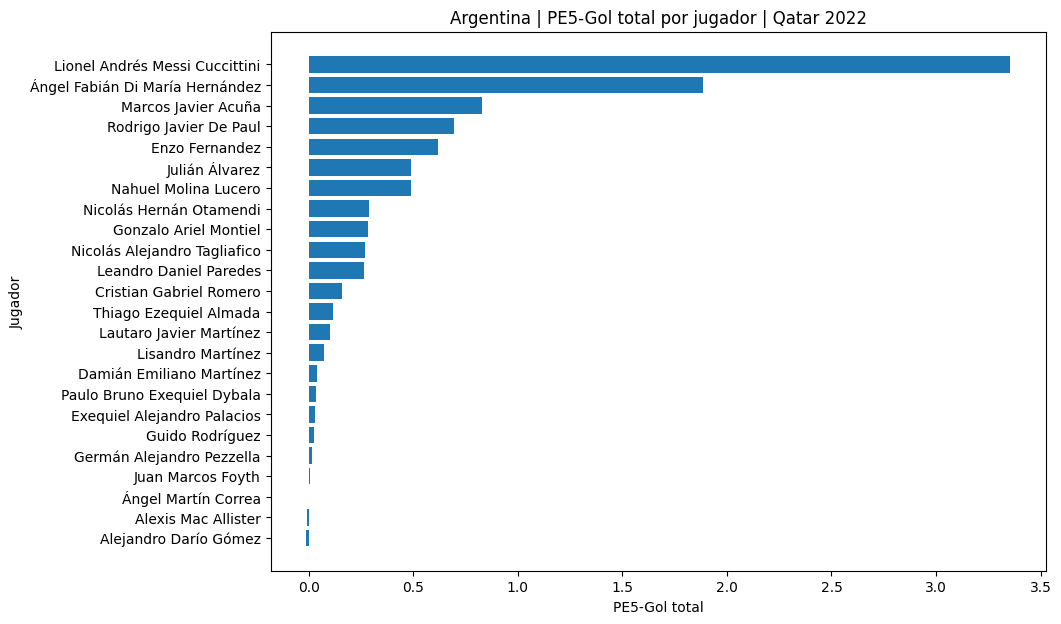

In [124]:
mundial_elegido = "Qatar 2022"

df_grafico = df_ranking_jugadores_arg[df_ranking_jugadores_arg["mundial"] == mundial_elegido].copy()

df_grafico = df_grafico.sort_values("pe5_total", ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(df_grafico["player"],df_grafico["pe5_total"])

plt.title("Argentina | PE5-Gol total por jugador | " + mundial_elegido)
plt.xlabel("PE5-Gol total")
plt.ylabel("Jugador")

plt.show()

Grafico PE5 positivo por jugador.

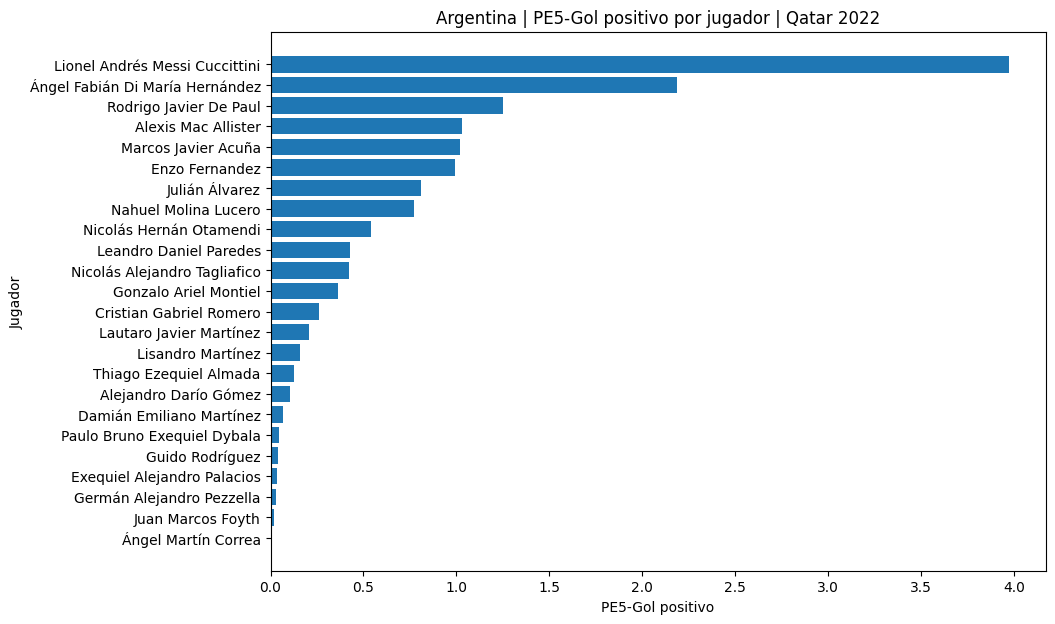

In [125]:
df_grafico = df_ranking_jugadores_arg[df_ranking_jugadores_arg["mundial"] == mundial_elegido].copy()

df_grafico = df_grafico.sort_values("pe5_positivo", ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(df_grafico["player"],df_grafico["pe5_positivo"])

plt.title("Argentina | PE5-Gol positivo por jugador | " + mundial_elegido)
plt.xlabel("PE5-Gol positivo")
plt.ylabel("Jugador")

plt.show()

In [126]:
df_tipo_grafico = df_ranking_tipo_arg[df_ranking_tipo_arg["mundial"] == mundial_elegido].copy()

Preparo matriz jugador-tipo de acción.

In [127]:
df_tipo_pivot = df_tipo_grafico.pivot_table(index="player",columns="tipo_accion_valorada",values="pe5_total",aggfunc="sum",fill_value=0).reset_index()

In [128]:
df_tipo_pivot.head()

tipo_accion_valorada,player,Carry,Pass
0,Alejandro Darío Gómez,0.007609,-0.022352
1,Alexis Mac Allister,-0.043773,0.036555
2,Cristian Gabriel Romero,0.020115,0.138482
3,Damián Emiliano Martínez,-0.004207,0.041954
4,Enzo Fernandez,0.175323,0.442196


In [129]:
if "Pass" not in df_tipo_pivot.columns:
    df_tipo_pivot["Pass"] = 0

if "Carry" not in df_tipo_pivot.columns:
    df_tipo_pivot["Carry"] = 0

In [130]:
df_tipo_pivot["pe5_total"] = df_tipo_pivot["Pass"] + df_tipo_pivot["Carry"]

df_tipo_pivot = df_tipo_pivot.sort_values("pe5_total", ascending=True)

Grafico PE5 por pases y conducciones.

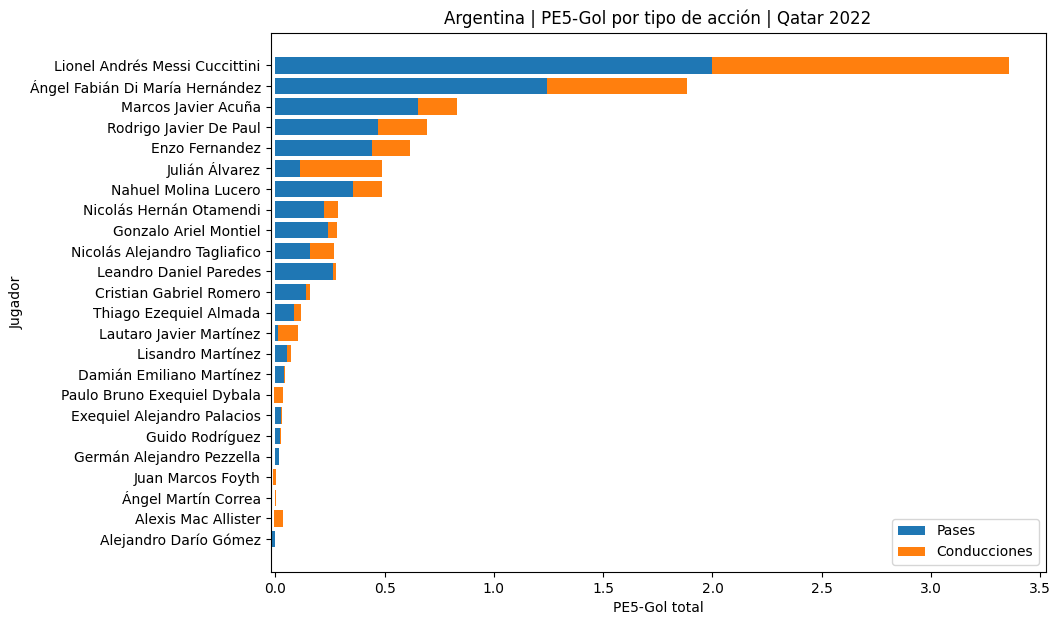

In [131]:
plt.figure(figsize=(10, 7))

plt.barh(df_tipo_pivot["player"],df_tipo_pivot["Pass"],label="Pases")

plt.barh(df_tipo_pivot["player"],df_tipo_pivot["Carry"],left=df_tipo_pivot["Pass"],label="Conducciones")

plt.title("Argentina | PE5-Gol por tipo de acción | " + mundial_elegido)
plt.xlabel("PE5-Gol total")
plt.ylabel("Jugador")
plt.legend()

plt.show()

In [132]:
df_top_acciones_arg = df_acciones_argentina.sort_values("incremento_pe5",ascending=False)

df_top_acciones_arg[["mundial","match_id","minute","home_team","away_team","team","player","tipo_accion_valorada","zona","zona_destino","valor_origen","valor_destino","incremento_pe5"]].head(20)

,mundial,match_id,minute,home_team,away_team,team,player,tipo_accion_valorada,zona,zona_destino,valor_origen,valor_destino,incremento_pe5
97078,Qatar 2022,3869321,12,Netherlands,Argentina,Argentina,Marcos Javier Acuña,Pass,8_0,11_3,0.002013,0.202083,0.200070
88430,Qatar 2022,3857300,100,Argentina,Saudi Arabia,Argentina,Ángel Fabián Di María Hernández,Pass,8_6,11_3,0.003223,0.202083,0.198861
2214,Rusia 2018,7531,3,Argentina,Iceland,Argentina,Lionel Andrés Messi Cuccittini,Pass,8_0,11_4,0.002013,0.198347,0.196334
37510,Rusia 2018,7580,92,France,Argentina,Argentina,Lionel Andrés Messi Cuccittini,Pass,8_5,11_3,0.006228,0.202083,0.195855
97413,Qatar 2022,3869321,47,Netherlands,Argentina,Argentina,Lionel Andrés Messi Cuccittini,Pass,11_0,11_3,0.007947,0.202083,0.194136
2407,Rusia 2018,7531,26,Argentina,Iceland,Argentina,Ángel Fabián Di María Hernández,Pass,11_0,11_3,0.007947,0.202083,0.194136
88299,Qatar 2022,3857300,68,Argentina,Saudi Arabia,Argentina,Lionel Andrés Messi Cuccittini,Pass,11_0,11_3,0.007947,0.202083,0.194136
101291,Qatar 2022,3869519,41,Argentina,Croatia,Argentina,Lionel Andrés Messi Cuccittini,Pass,11_0,11_3,0.007947,0.202083,0.194136
97978,Qatar 2022,3869321,115,Netherlands,Argentina,Argentina,Ángel Fabián Di María Hernández,Pass,11_0,11_3,0.007947,0.202083,0.194136
2866,Rusia 2018,7531,77,Argentina,Iceland,Argentina,Javier Alejandro Mascherano,Pass,8_4,11_3,0.008806,0.202083,0.193278


In [133]:
from mplsoccer import Pitch

Filtro acciones top de un jugador elegido.

In [134]:
jugador_elegido = "Lionel Andrés Messi Cuccittini"
mundial_elegido = "Qatar 2022"

df_jugador_acciones = df_acciones_argentina[
    (df_acciones_argentina["player"] == jugador_elegido) &
    (df_acciones_argentina["mundial"] == mundial_elegido)
].copy()

df_jugador_acciones = df_jugador_acciones.sort_values(
    "incremento_pe5",
    ascending=False
)

df_jugador_top = df_jugador_acciones.head(15).copy()

Dibujo acciones top del jugador en cancha.

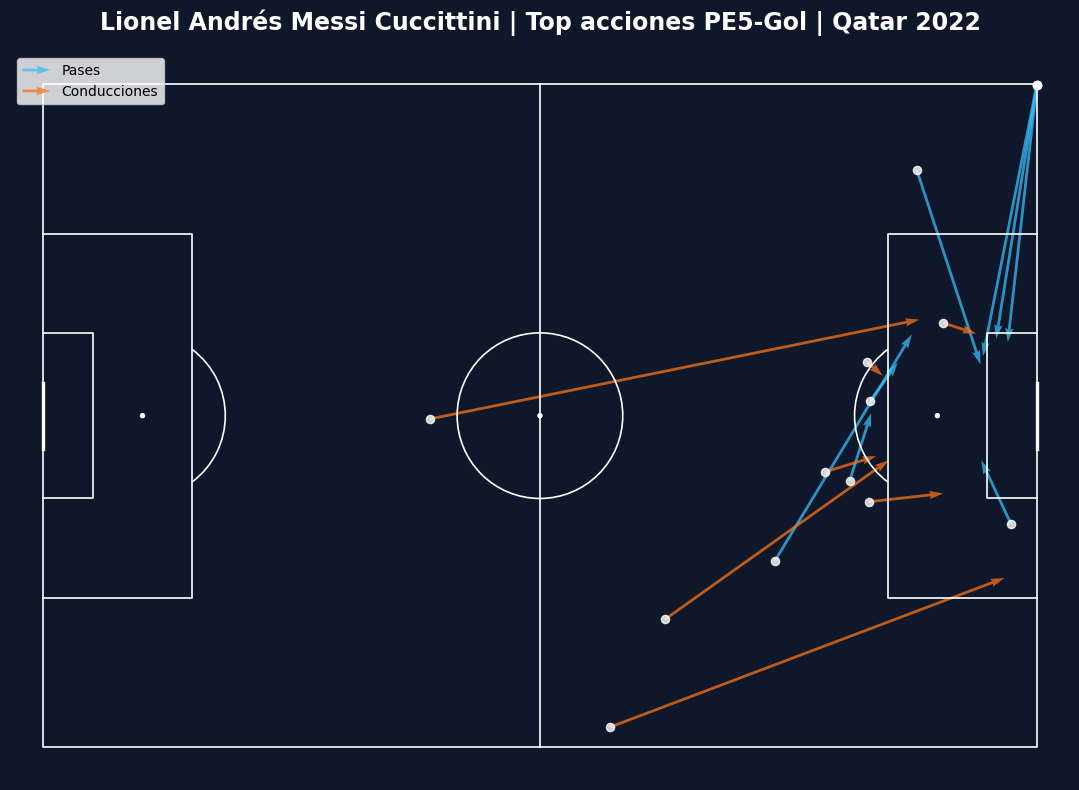

In [135]:
cancha = Pitch(
    pitch_type="statsbomb",
    pitch_color="#0f172a",
    line_color="white",
    linewidth=1.2,
    line_zorder=3
)

fig, ax = cancha.draw(figsize=(13, 8))
fig.set_facecolor("#0f172a")

df_pases_top = df_jugador_top[
    df_jugador_top["tipo_accion_valorada"] == "Pass"
].copy()

cancha.arrows(
    df_pases_top["x"],
    df_pases_top["y"],
    df_pases_top["x_fin"],
    df_pases_top["y_fin"],
    ax=ax,
    color="#38bdf8",
    width=2,
    alpha=0.75,
    label="Pases"
)

df_carries_top = df_jugador_top[
    df_jugador_top["tipo_accion_valorada"] == "Carry"
].copy()

cancha.arrows(
    df_carries_top["x"],
    df_carries_top["y"],
    df_carries_top["x_fin"],
    df_carries_top["y_fin"],
    ax=ax,
    color="#f97316",
    width=2,
    alpha=0.75,
    label="Conducciones"
)

cancha.scatter(
    df_jugador_top["x"],
    df_jugador_top["y"],
    ax=ax,
    s=35,
    color="white",
    alpha=0.80
)

ax.set_title(
    jugador_elegido + " | Top acciones PE5-Gol | " + mundial_elegido,
    color="white",
    fontsize=17,
    pad=15,
    fontweight="bold"
)

plt.legend()
plt.show()

In [136]:
df_partidos_arg_pe5[df_partidos_arg_pe5["mundial"] == "Qatar 2022"]

,mundial,match_id,home_team,away_team,acciones_valoradas,pe5_total,pe5_positivo,pe5_negativo
2,Qatar 2022,3857300,Argentina,Saudi Arabia,1054,2.202422,2.746209,-0.543787
0,Qatar 2022,3857264,Poland,Argentina,1603,2.008051,3.139692,-1.131641
6,Qatar 2022,3869685,Argentina,France,1042,1.669991,2.255498,-0.585507
4,Qatar 2022,3869321,Netherlands,Argentina,1026,1.238159,2.291930,-1.053770
5,Qatar 2022,3869519,Argentina,Croatia,666,1.091211,1.512287,-0.421077
3,Qatar 2022,3869151,Argentina,Australia,1279,0.999086,1.689461,-0.690375
1,Qatar 2022,3857289,Argentina,Mexico,910,0.823926,1.236606,-0.412680


In [137]:
match_id_elegido = 3869685

In [138]:
df_partidos_arg_pe5[
    (df_partidos_arg_pe5["home_team"].str.contains("Argentina", case=False, na=False)) |
    (df_partidos_arg_pe5["away_team"].str.contains("Argentina", case=False, na=False))
]

,mundial,match_id,home_team,away_team,acciones_valoradas,pe5_total,pe5_positivo,pe5_negativo
7,Rusia 2018,7531,Argentina,Iceland,1371,2.995600,4.678486,-1.682886
2,Qatar 2022,3857300,Argentina,Saudi Arabia,1054,2.202422,2.746209,-0.543787
0,Qatar 2022,3857264,Poland,Argentina,1603,2.008051,3.139692,-1.131641
6,Qatar 2022,3869685,Argentina,France,1042,1.669991,2.255498,-0.585507
10,Rusia 2018,7580,France,Argentina,922,1.563196,2.113148,-0.549952
4,Qatar 2022,3869321,Netherlands,Argentina,1026,1.238159,2.291930,-1.053770
9,Rusia 2018,7564,Nigeria,Argentina,944,1.114678,1.724198,-0.609520
5,Qatar 2022,3869519,Argentina,Croatia,666,1.091211,1.512287,-0.421077
8,Rusia 2018,7545,Argentina,Croatia,855,1.021186,1.439692,-0.418506
3,Qatar 2022,3869151,Argentina,Australia,1279,0.999086,1.689461,-0.690375


Preparo evolución PE5 de un partido.

In [139]:
df_partido_linea = df_acciones_argentina[df_acciones_argentina["match_id"] == match_id_elegido].copy()

df_partido_linea = df_partido_linea.sort_values(["period", "minute", "second", "index"]).reset_index(drop=True)

Calculo PE5 acumulado del partido.

In [140]:
df_partido_linea["pe5_acumulado"] = df_partido_linea["incremento_pe5"].cumsum()

Grafico PE5 acumulado por minuto.

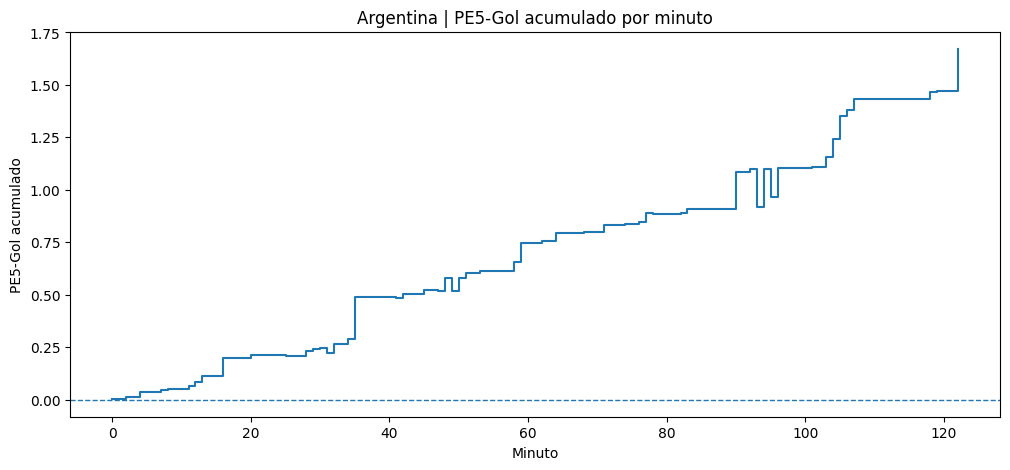

In [141]:
df_partido_minuto = df_partido_linea[["minute", "pe5_acumulado"]].copy()

df_partido_minuto = df_partido_minuto.groupby("minute").last().reset_index()

minuto_maximo = int(df_partido_linea["minute"].max())

df_minutos = pd.DataFrame()
df_minutos["minute"] = range(0, minuto_maximo + 1)

df_partido_minuto = df_minutos.merge(df_partido_minuto, on="minute", how="left")

df_partido_minuto["pe5_acumulado"] = df_partido_minuto["pe5_acumulado"].ffill()

df_partido_minuto["pe5_acumulado"] = df_partido_minuto["pe5_acumulado"].fillna(0)

plt.figure(figsize=(12, 5))

plt.step(df_partido_minuto["minute"], df_partido_minuto["pe5_acumulado"], where="post")

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Argentina | PE5-Gol acumulado por minuto")
plt.xlabel("Minuto")
plt.ylabel("PE5-Gol acumulado")

plt.show()

Guardo valor de zonas, acciones valoradas y partidos en Parquet

In [144]:
ruta_processed = Path("../data/processed")
ruta_processed.mkdir(parents=True, exist_ok=True)

df_valor_zonas.to_parquet(ruta_processed/"pe5_valor_zonas.parquet", index=False)

df_acciones_valoradas.to_parquet(ruta_processed/"pe5_acciones_valoradas.parquet", index=False)

df_partidos_mundiales.to_parquet(ruta_processed/"partidos_mundiales.parquet", index=False)

Guardo valor de zonas, acciones valoradas y partidos en CSV

In [145]:
ruta_processed = Path("../data/processed")
ruta_processed.mkdir(parents=True, exist_ok=True)

df_valor_zonas.to_csv(ruta_processed/"pe5_valor_zonas.csv", index=False)

df_acciones_valoradas.to_csv(ruta_processed/"pe5_acciones_valoradas.csv", index=False)

df_partidos_mundiales.to_csv(ruta_processed/"partidos_mundiales.csv", index=False)